In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV, cross_val_score

print('All libraries imported successfully')

All libraries imported successfully


### Cell 1 — Load dataset

In [7]:
def load_data():
    print('Loading UCI HAR Dataset...')
    data_folder = 'C:\\Users\\workstation\\OneDrive\\Afbeeldingen\\library py\\fri_practice\\UCI HAR Dataset\\'
    features    = pd.read_csv(data_folder + 'features.txt', sep='\\s+', header=None, names=['id','name'])
    columnNames = features['name'].values
    labelsMap   = pd.read_csv(data_folder + 'activity_labels.txt', sep='\\s+', header=None, names=['id','activity_name'])

    def read_set(set_name):
        X       = pd.read_csv(f'{data_folder}{set_name}/X_{set_name}.txt', sep='\\s+', header=None)
        X.columns = columnNames
        y       = pd.read_csv(f'{data_folder}{set_name}/y_{set_name}.txt', sep='\\s+', header=None, names=['Activity_ID'])
        y['Activity_Name'] = y['Activity_ID'].map(labelsMap.set_index('id')['activity_name'])
        subject = pd.read_csv(f'{data_folder}{set_name}/subject_{set_name}.txt', sep='\\s+', header=None, names=['Subject_ID'])
        return pd.concat([subject, y, X], axis=1)

    train_df = read_set('train')
    test_df  = read_set('test')
    print(f'Train shape : {train_df.shape}')
    print(f'Test  shape : {test_df.shape}')
    return train_df, test_df

train_data, test_data = load_data()
train_data.head(3)

Loading UCI HAR Dataset...
Train shape : (7352, 564)
Test  shape : (2947, 564)


,Subject_ID,Activity_ID,Activity_Name,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118


### Cell 2 — Load raw inertial signals

In [12]:
def load_inertial_signals(set_name):
    print(f'Loading raw signals for {set_name}...')
    data_folder = f'C:\\Users\\workstation\\OneDrive\\Afbeeldingen\\library py\\fri_practice\\UCI HAR Dataset\\{set_name}/Inertial Signals/'
    filenames = [
        'body_acc_x_','body_acc_y_','body_acc_z_',
        'body_gyro_x_','body_gyro_y_','body_gyro_z_',
        'total_acc_x_','total_acc_y_','total_acc_z_'
    ]
    signals = []
    for name in filenames:
        data = pd.read_csv(f'{data_folder}{name}{set_name}.txt', sep='\\s+', header=None)
        signals.append(data.values)
    return np.transpose(np.array(signals), (1, 2, 0))

X_train_raw = load_inertial_signals('train')
X_test_raw  = load_inertial_signals('test')
print(f'X_train_raw shape : {X_train_raw.shape}  -> (samples, timesteps, signals)')
print(f'X_test_raw  shape : {X_test_raw.shape}')

Loading raw signals for train...
Loading raw signals for test...
X_train_raw shape : (7352, 128, 9)  -> (samples, timesteps, signals)
X_test_raw  shape : (2947, 128, 9)


### Cell 3 — Data quality checks

In [13]:
print('=== Data Quality Report ===')
print(f'NaN in train     : {train_data.isnull().sum().sum()}')
print(f'NaN in test      : {test_data.isnull().sum().sum()}')
print(f'Duplicate rows   : {train_data.duplicated().sum()}')
print()
print('=== Train / Test Split ===')
total = train_data.shape[0] + test_data.shape[0]
print(f'Train : {train_data.shape[0]} samples ({train_data.shape[0]/total:.0%})')
print(f'Test  : {test_data.shape[0]} samples ({test_data.shape[0]/total:.0%})')
print()
print('=== Class Distribution (train) ===')
print(train_data['Activity_Name'].value_counts())

=== Data Quality Report ===
NaN in train     : 0
NaN in test      : 0
Duplicate rows   : 0

=== Train / Test Split ===
Train : 7352 samples (71%)
Test  : 2947 samples (29%)

=== Class Distribution (train) ===
Activity_Name
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


### Cell 4 — Activity class balance

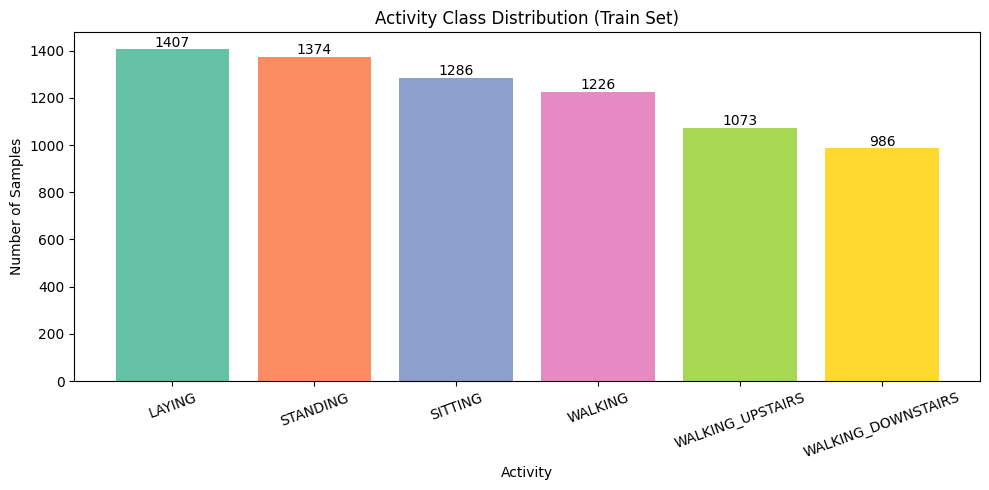

Insight: Classes are roughly balanced — no major imbalance issue.


In [14]:
plt.figure(figsize=(10, 5))
counts = train_data['Activity_Name'].value_counts()
bars = plt.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
plt.title('Activity Class Distribution (Train Set)')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=20)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Insight: Classes are roughly balanced — no major imbalance issue.')

### Cell 5 — Sensor signal plots per activity

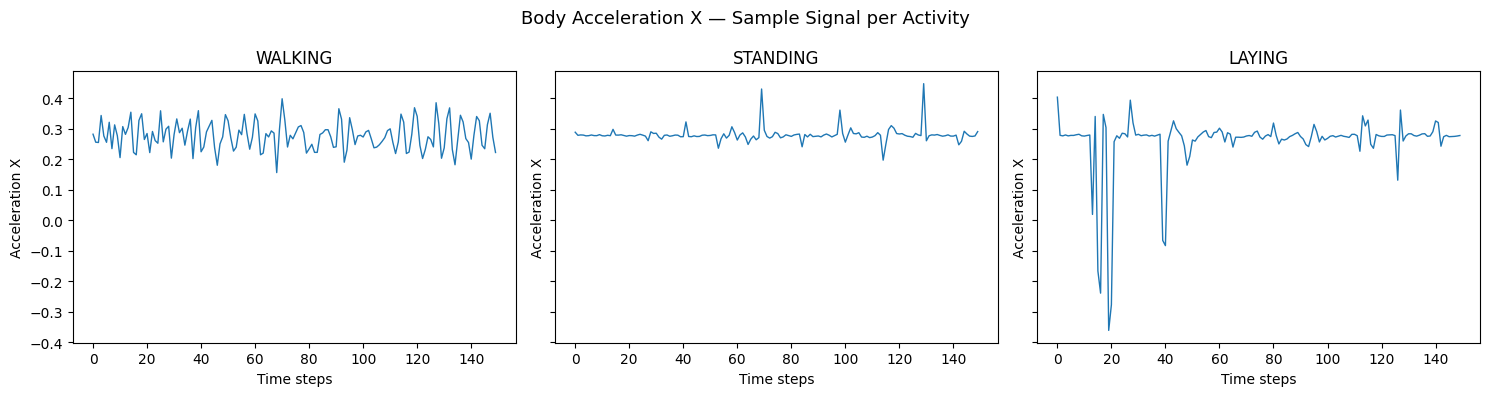

Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.


In [15]:
activities  = ['WALKING', 'STANDING', 'LAYING']
signal_col  = 'tBodyAcc-mean()-X'
fig, axes   = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, activity in zip(axes, activities):
    subset = train_data[train_data['Activity_Name'] == activity][signal_col].values[:150]
    ax.plot(subset, linewidth=1)
    ax.set_title(f'{activity}')
    ax.set_xlabel('Time steps')
    ax.set_ylabel('Acceleration X')

plt.suptitle('Body Acceleration X — Sample Signal per Activity', fontsize=13)
plt.tight_layout()
plt.show()
print('Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.')

### Cell 6 — Correlation matrix (first 20 features)

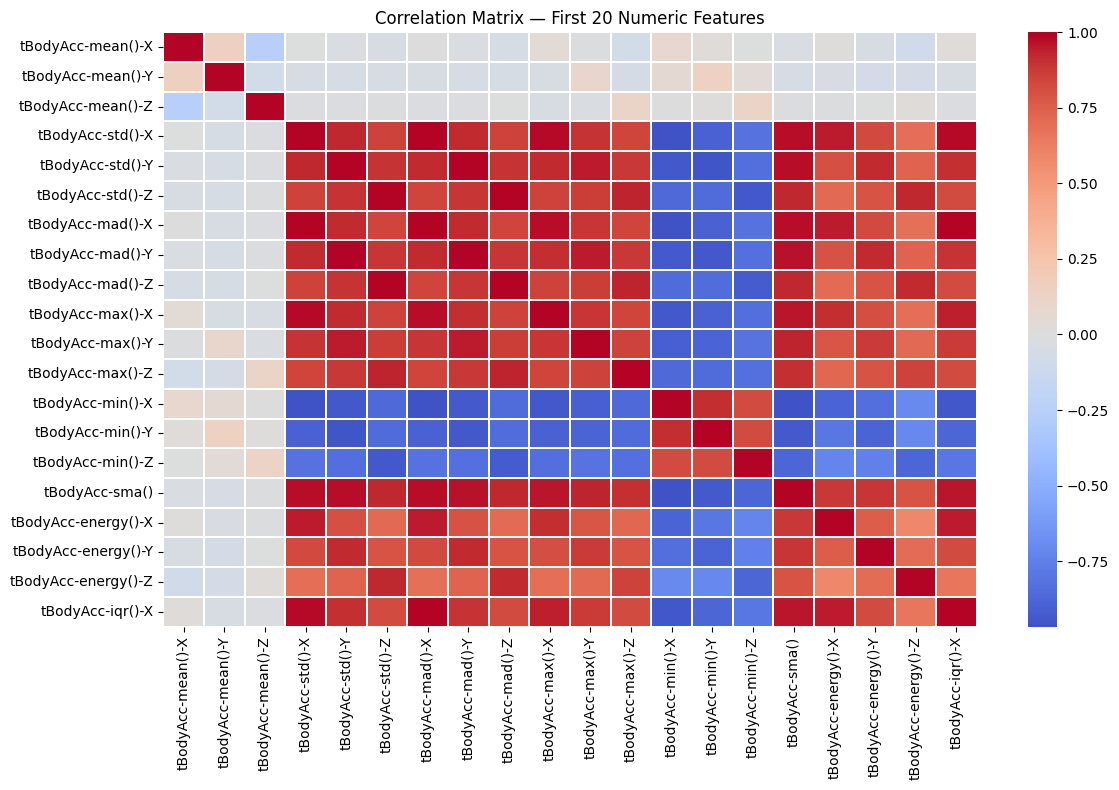

Insight: High correlation between some body acceleration features — expected for XYZ axes.


In [16]:
numeric_data = train_data.select_dtypes(include=['number'])
corr = numeric_data.iloc[:, 2:22].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title('Correlation Matrix — First 20 Numeric Features')
plt.tight_layout()
plt.show()
print('Insight: High correlation between some body acceleration features — expected for XYZ axes.')

### Cell 7 — Distribution plots

C:\Users\workstation\AppData\Local\Temp\ipykernel_16712\2706673080.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')


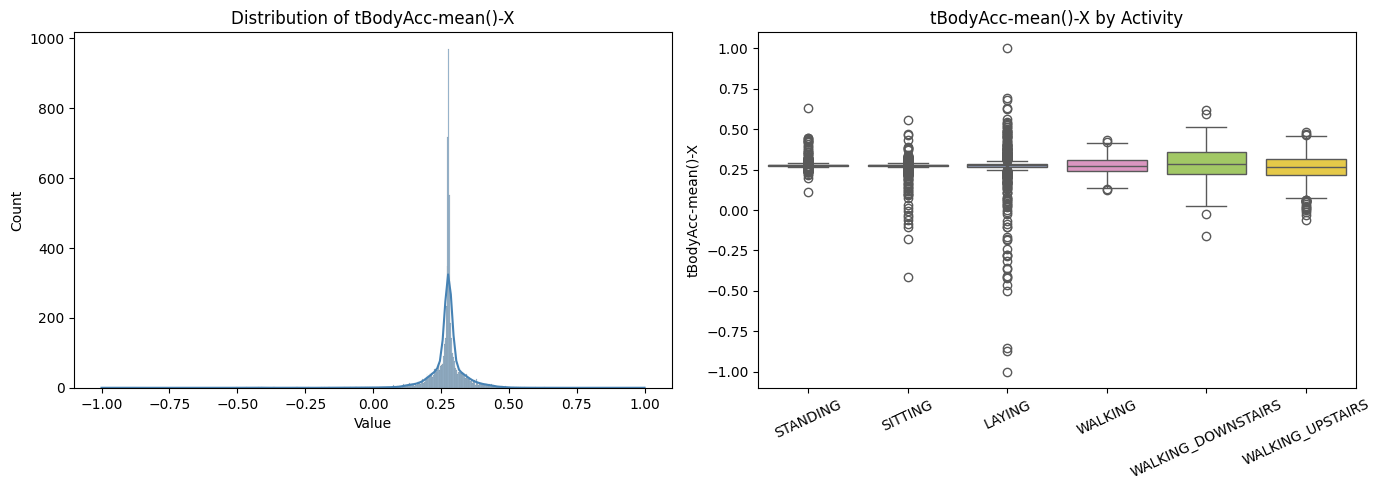

Insight: Body acceleration X clearly separates walking activities from static ones.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(numeric_data.iloc[:, 2], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribution of {numeric_data.columns[2]}')
axes[0].set_xlabel('Value')


feature = 'tBodyAcc-mean()-X'
sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')
axes[1].set_title(f'{feature} by Activity')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
print('Insight: Body acceleration X clearly separates walking activities from static ones.')

### Cell 8 — Signal names

In [18]:
SIGNAL_NAMES = [
    'body_acc_x','body_acc_y','body_acc_z',
    'body_gyro_x','body_gyro_y','body_gyro_z',
    'total_acc_x','total_acc_y','total_acc_z'
]
print(f'Number of signals : {len(SIGNAL_NAMES)}')
print(f'Signal names      : {SIGNAL_NAMES}')

Number of signals : 9
Signal names      : ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


### Cell 9 — Time-domain features (mean, std, min, max, median, skew, kurtosis)

In [19]:
def extract_time_domain_features(raw_data):
    print('Extracting time-domain features...')
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal = sample[:, i]
            row[f'{sig_name}_mean']     = np.mean(signal)
            row[f'{sig_name}_std']      = np.std(signal)
            row[f'{sig_name}_min']      = np.min(signal)
            row[f'{sig_name}_max']      = np.max(signal)
            row[f'{sig_name}_median']   = np.median(signal)
            row[f'{sig_name}_skew']     = skew(signal)
            row[f'{sig_name}_kurtosis'] = kurtosis(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 7 stats = 63 features)')
    return df

X_train_time = extract_time_domain_features(X_train_raw)
X_test_time  = extract_time_domain_features(X_test_raw)
X_train_time.head(3)

Extracting time-domain features...
  Output shape : (7352, 63)  (9 signals x 7 stats = 63 features)
Extracting time-domain features...
  Output shape : (2947, 63)  (9 signals x 7 stats = 63 features)


,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,body_acc_y_mean,body_acc_y_std,body_acc_y_min,...,total_acc_y_median,total_acc_y_skew,total_acc_y_kurtosis,total_acc_z_mean,total_acc_z_std,total_acc_z_min,total_acc_z_max,total_acc_z_median,total_acc_z_skew,total_acc_z_kurtosis
0,0.002269,0.002941,-0.004294,0.010810,0.002025,0.481111,-0.395797,-0.001655,0.004601,-0.012610,...,-0.124302,-0.034474,-0.408672,0.099732,0.003970,0.088742,0.109485,0.099841,0.071125,0.493800
1,0.000174,0.001981,-0.006706,0.005251,0.000110,-0.480776,1.472747,0.000382,0.005930,-0.012610,...,-0.123188,0.488232,0.163722,0.096939,0.004918,0.081100,0.105788,0.097748,-1.084209,1.257869
2,0.000428,0.002908,-0.010483,0.008167,0.000627,-0.565241,1.802622,-0.001222,0.007310,-0.015333,...,-0.125918,0.366785,-0.640148,0.092897,0.006145,0.081100,0.105788,0.093636,-0.144007,-0.716645


### Cell 10 — Frequency-domain features (FFT)

In [20]:
def spectral_entropy(signal):
    fft_vals = np.abs(fft(signal))[:len(signal)//2]
    power    = fft_vals ** 2
    total    = np.sum(power)
    if total == 0:
        return 0.0
    prob = power / total
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def extract_fft_features(raw_data, sampling_rate=50):
    print('Extracting FFT features...')
    n_timesteps = raw_data.shape[1]
    freqs       = np.fft.fftfreq(n_timesteps, d=1.0/sampling_rate)[:n_timesteps//2]
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal   = sample[:, i]
            fft_vals = np.abs(fft(signal))[:n_timesteps//2]
            row[f'{sig_name}_fft_dominant_freq']    = freqs[np.argmax(fft_vals)]
            row[f'{sig_name}_fft_energy']           = np.sum(fft_vals ** 2)
            row[f'{sig_name}_fft_spectral_entropy'] = spectral_entropy(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 3 stats = 27 features)')
    return df

X_train_fft = extract_fft_features(X_train_raw)
X_test_fft  = extract_fft_features(X_test_raw)
X_train_fft.head(3)

Extracting FFT features...
  Output shape : (7352, 27)  (9 signals x 3 stats = 27 features)
Extracting FFT features...
  Output shape : (2947, 27)  (9 signals x 3 stats = 27 features)


,body_acc_x_fft_dominant_freq,body_acc_x_fft_energy,body_acc_x_fft_spectral_entropy,body_acc_y_fft_dominant_freq,body_acc_y_fft_energy,body_acc_y_fft_spectral_entropy,body_acc_z_fft_dominant_freq,body_acc_z_fft_energy,body_acc_z_fft_spectral_entropy,body_gyro_x_fft_dominant_freq,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,0.00000,0.155185,2.610402,0.390625,0.218277,3.594107,0.390625,3.886445,2.556959,0.000000,...,1.344905,0.0,17022.704179,0.000040,0.0,253.073153,0.006050,0.0,163.091410,0.012904
1,7.03125,0.032640,4.761714,0.390625,0.290422,3.365968,0.000000,1.252940,2.680912,0.000000,...,2.333451,0.0,17027.498428,0.000045,0.0,247.813017,0.012676,0.0,154.162921,0.019843
2,0.78125,0.072294,4.779093,0.390625,0.462221,2.989540,0.390625,0.424719,3.435523,0.390625,...,3.248716,0.0,17043.526416,0.000098,0.0,256.328623,0.019163,0.0,141.700207,0.030712


### Cell 11 — Combine all features (63 + 27 = 90)

In [21]:
X_train_feats = pd.concat([X_train_time, X_train_fft], axis=1)
X_test_feats  = pd.concat([X_test_time,  X_test_fft],  axis=1)
print(f'X_train_feats : {X_train_feats.shape}')
print(f'X_test_feats  : {X_test_feats.shape}')
print(f'Total features: {X_train_feats.shape[1]}  (63 time-domain + 27 FFT)')

X_train_feats : (7352, 90)
X_test_feats  : (2947, 90)
Total features: 90  (63 time-domain + 27 FFT)


### Cell 12 — StandardScaler (fit on train only)

In [22]:
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_feats), columns=X_train_feats.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_feats),      columns=X_test_feats.columns)
print(f'Train scaled shape : {X_train_scaled.shape}')
print(f'Test  scaled shape : {X_test_scaled.shape}')
print('\nVerify — train mean should be ~0 and std ~1:')
print(X_train_scaled.describe().loc[['mean','std']].round(3).iloc[:, :5])

Train scaled shape : (7352, 90)
Test  scaled shape : (2947, 90)

Verify — train mean should be ~0 and std ~1:
      body_acc_x_mean  body_acc_x_std  body_acc_x_min  body_acc_x_max  \
mean              0.0             0.0             0.0            -0.0   
std               1.0             1.0             1.0             1.0   

      body_acc_x_median  
mean               -0.0  
std                 1.0  


### Cell 13 — Attach labels and export CSVs

In [23]:
train_labels = train_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)
test_labels  = test_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)

train_final = pd.concat([train_labels, X_train_scaled.reset_index(drop=True)], axis=1)
test_final  = pd.concat([test_labels,  X_test_scaled.reset_index(drop=True)],  axis=1)

train_final.to_csv('train_features.csv', index=False)
test_final.to_csv('test_features.csv',   index=False)

print('Saved: train_features.csv')
print('Saved: test_features.csv')
print(f'\ntrain_final shape : {train_final.shape}')
print(f'test_final  shape : {test_final.shape}')
train_final.head(3)

Saved: train_features.csv
Saved: test_features.csv

train_final shape : (7352, 93)
test_final  shape : (2947, 93)


,Subject_ID,Activity_ID,Activity_Name,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,1,5,STANDING,0.200642,-0.868814,0.906009,-0.856036,0.587177,0.383365,-0.331063,...,-1.676605,-0.04378,0.610645,-0.550501,-0.129234,-0.587056,-0.818857,-0.274773,-0.566725,-0.812263
1,1,5,STANDING,0.055948,-0.875426,0.895998,-0.871359,0.544547,-1.181161,0.631206,...,-0.703240,-0.04378,0.611394,-0.550488,-0.129234,-0.588493,-0.813157,-0.274773,-0.569294,-0.807098
2,1,5,STANDING,0.073515,-0.869039,0.880323,-0.863323,0.556060,-1.318546,0.801087,...,0.197969,-0.04378,0.613897,-0.550355,-0.129234,-0.586166,-0.807577,-0.274773,-0.572879,-0.799007


### Cell 14 — PCA Visualization (Dimensionality Reduction)

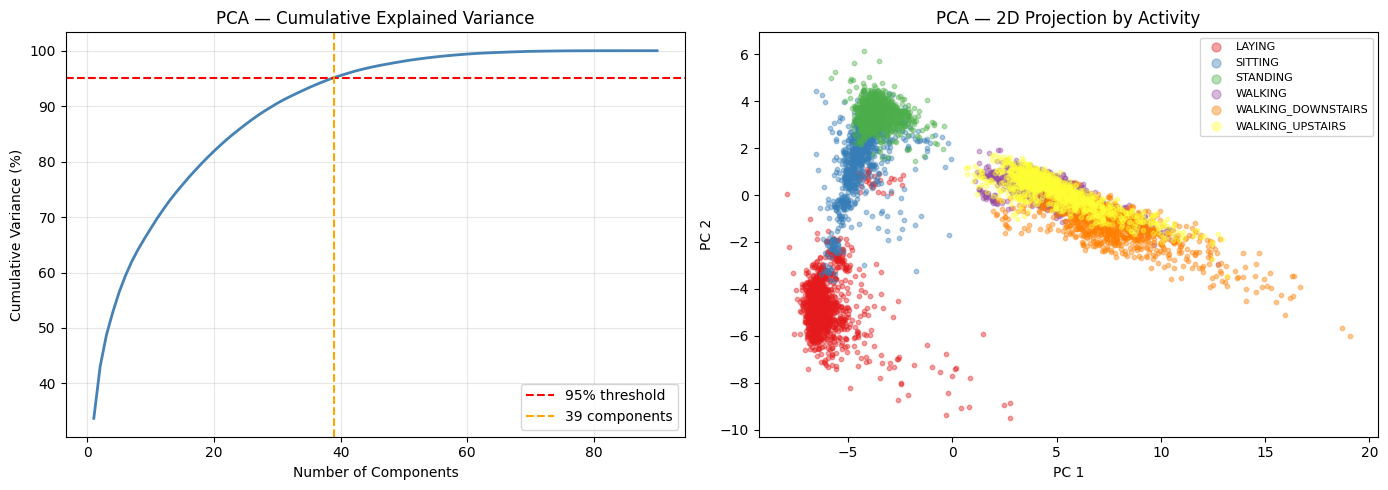

Insight: 39 components explain 95% of variance (out of 90 original features)


In [ ]:
feature_cols = X_train_scaled.columns.tolist()
X_train      = train_final[feature_cols]
y_train      = train_final['Activity_ID']
X_test       = test_final[feature_cols]
y_test       = test_final['Activity_ID']

pca_full     = PCA()
pca_full.fit(X_train)
cumvar        = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95          = np.argmax(cumvar >= 95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(range(1, len(cumvar)+1), cumvar, color='steelblue', linewidth=2)
axes[0].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[0].axvline(x=n_95, color='orange', linestyle='--', label=f'{n_95} components')
axes[0].set_title('PCA — Cumulative Explained Variance')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


pca2d     = PCA(n_components=2)
X_pca2d   = pca2d.fit_transform(X_train)
activity_names = train_final['Activity_Name'].values
unique_acts    = np.unique(activity_names)
colors         = sns.color_palette('Set1', len(unique_acts))

for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    axes[1].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], label=act, alpha=0.4, s=10, color=col)

axes[1].set_title('PCA — 2D Projection by Activity')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()
print(f'Insight: {n_95} components explain 95% of variance (out of {X_train.shape[1]} original features)')

### Cell 15 — LDA Visualization

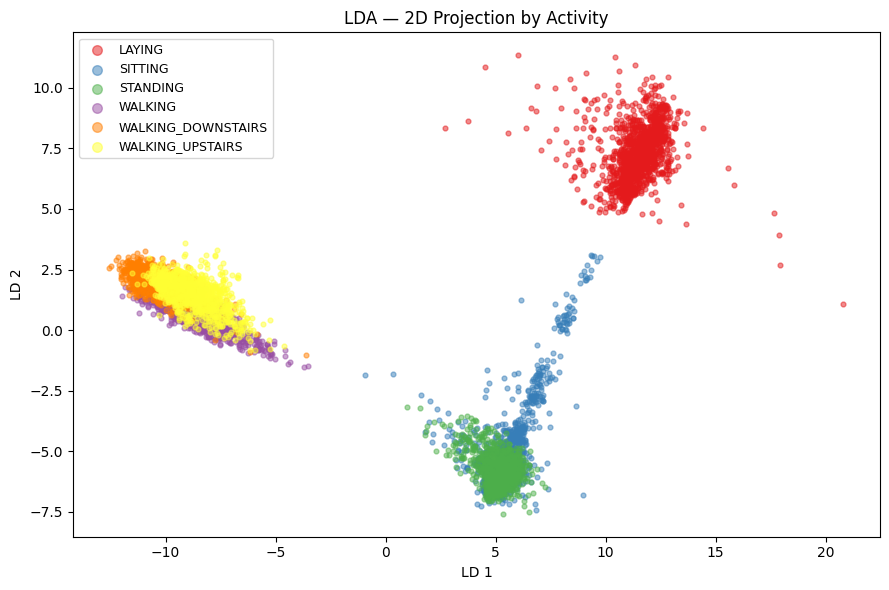

Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.


In [25]:
lda     = LDA(n_components=2)
X_lda2d = lda.fit_transform(X_train, y_train)

plt.figure(figsize=(9, 6))
for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    plt.scatter(X_lda2d[mask, 0], X_lda2d[mask, 1], label=act, alpha=0.5, s=12, color=col)

plt.title('LDA — 2D Projection by Activity')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()
print('Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.')

### Cell 16 — Encode labels

In [26]:
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print('Classes:', le.classes_)
print('Encoded:', le.transform(le.classes_))

Classes: [1 2 3 4 5 6]
Encoded: [0 1 2 3 4 5]


### Cell 17 — Train all models (KNN, Naive Bayes, Random Forest, Gradient Boosting)

In [27]:
models = {
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'       : GaussianNB(),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test_enc, y_pred)
    f1     = f1_score(y_test_enc, y_pred, average='weighted')
    roc    = roc_auc_score(y_test_enc, model.predict_proba(X_test), multi_class='ovr', average='weighted')
    results.append({'Model': name, 'Accuracy': round(acc,4), 'F1 Score': round(f1,4), 'ROC AUC': round(roc,4)})
    trained_models[name] = (model, y_pred)
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc:.4f}')

results_df = pd.DataFrame(results)
print('\n=== Results Summary ===')
print(results_df.to_string(index=False))

Training KNN...
  Accuracy: 0.8514 | F1: 0.8517 | ROC AUC: 0.9717
Training Naive Bayes...
  Accuracy: 0.8405 | F1: 0.8344 | ROC AUC: 0.9820
Training Random Forest...
  Accuracy: 0.9019 | F1: 0.9017 | ROC AUC: 0.9914
Training Gradient Boosting...
  Accuracy: 0.9104 | F1: 0.9103 | ROC AUC: 0.9924

=== Results Summary ===
            Model  Accuracy  F1 Score  ROC AUC
              KNN    0.8514    0.8517   0.9717
      Naive Bayes    0.8405    0.8344   0.9820
    Random Forest    0.9019    0.9017   0.9914
Gradient Boosting    0.9104    0.9103   0.9924


### Cell 18 — Confusion matrices for all models

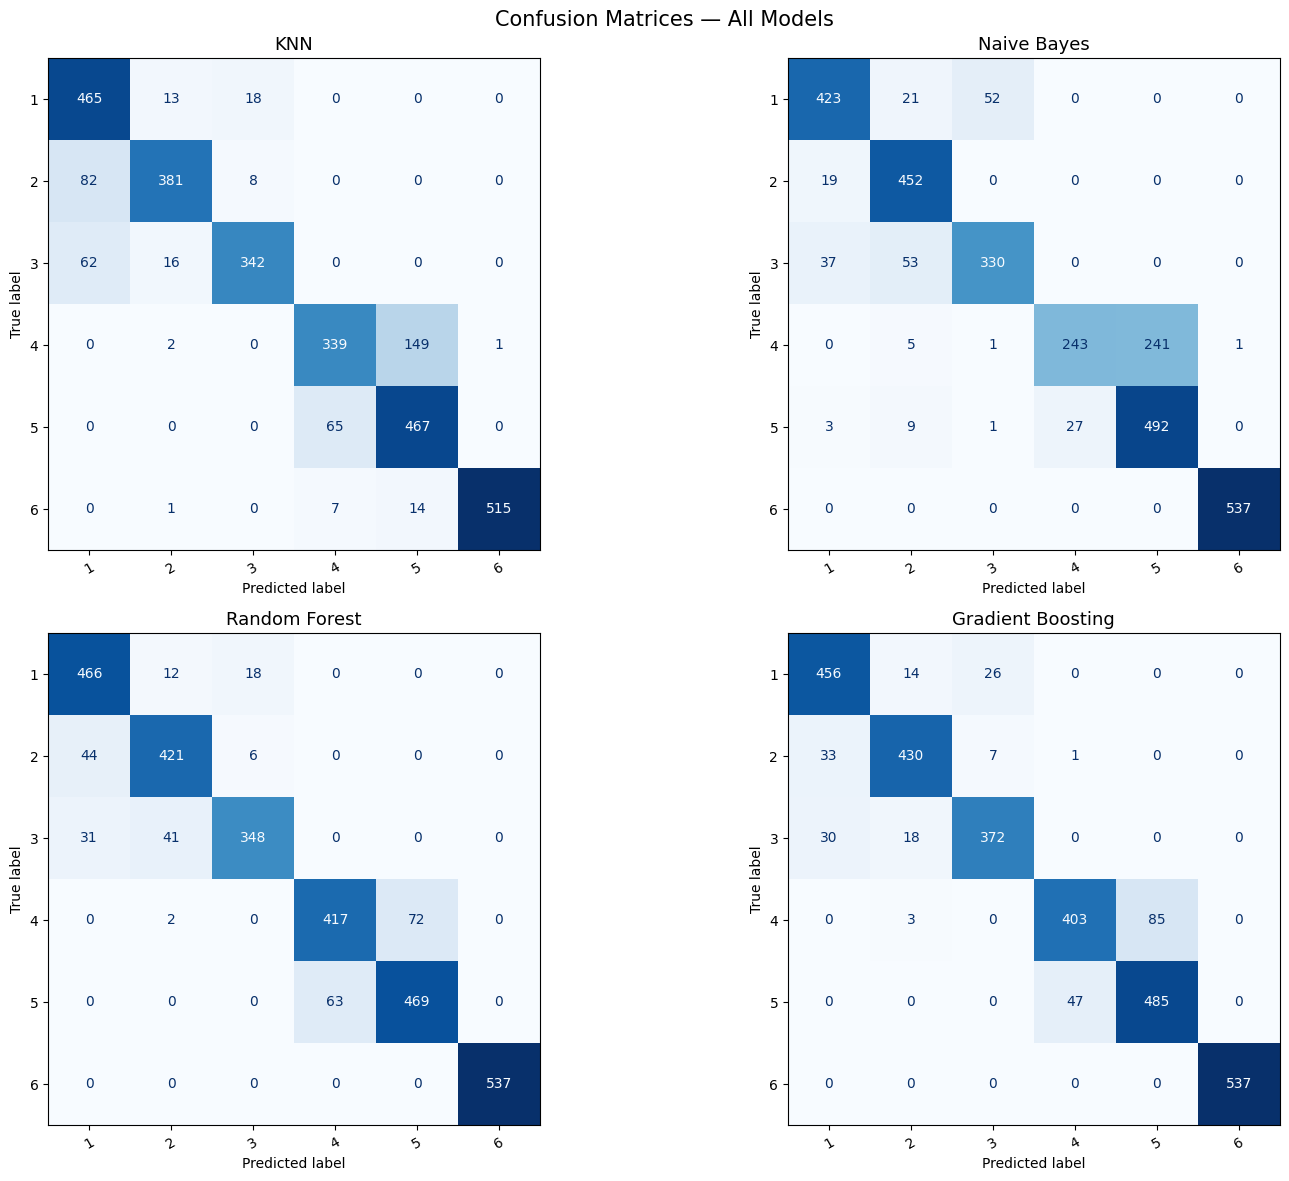

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, (model, y_pred)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=13)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.show()

### Cell 19 — Hyperparameter tuning (KNN & Random Forest)

In [29]:
print('Tuning KNN...')
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid   = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train_enc)
print(f'  Best k : {knn_grid.best_params_}  |  CV Accuracy : {knn_grid.best_score_:.4f}')

print('Tuning Random Forest...')
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
rf_grid   = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train_enc)
print(f'  Best params : {rf_grid.best_params_}  |  CV Accuracy : {rf_grid.best_score_:.4f}')

Tuning KNN...
  Best k : {'n_neighbors': 9}  |  CV Accuracy : 0.8679
Tuning Random Forest...
  Best params : {'max_depth': 10, 'n_estimators': 50}  |  CV Accuracy : 0.8852


### Cell 20 — Final results bar chart

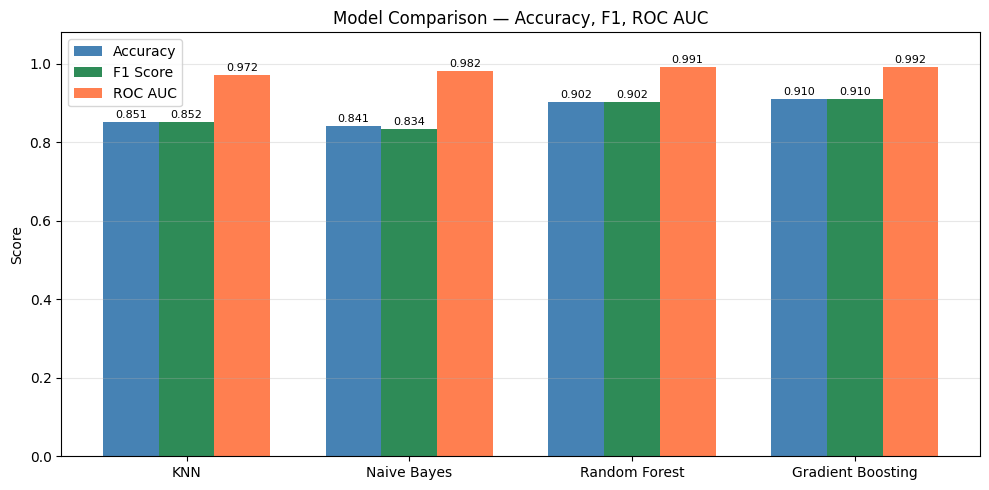

Best model by accuracy: Gradient Boosting


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(results_df))
width   = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x,         results_df['F1 Score'], width, label='F1 Score',  color='seagreen')
bars3 = ax.bar(x + width, results_df['ROC AUC'],  width, label='ROC AUC',   color='coral')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1.08)
ax.set_title('Model Comparison — Accuracy, F1, ROC AUC')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
best = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f'Best model by accuracy: {best}')